NORMALIZATION

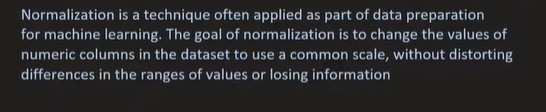

**BASICALLY SQUISHING DATA BETWEEN 0 TO 1**

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('wine.csv',header=None,usecols=[0,1,2])
df.columns = ['Class Label','Alcohol','Malic Acid']


In [ ]:
df['Malic Acid'].dtype

dtype('O')

<Axes: xlabel='Alcohol', ylabel='Density'>

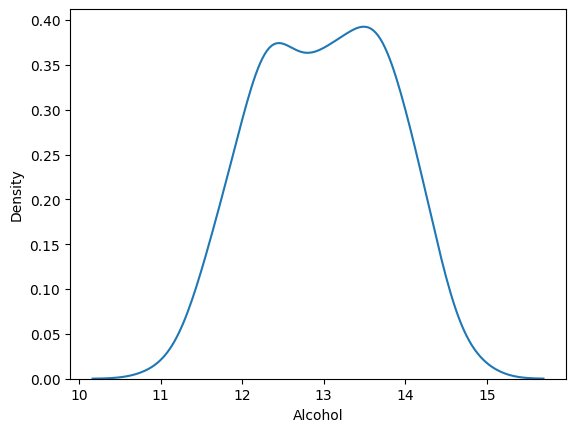

In [26]:
df['Alcohol'] = pd.to_numeric(df['Alcohol'], errors='coerce')
df['Malic Acid'] = pd.to_numeric(df['Malic Acid'], errors='coerce')
sns.kdeplot(df['Alcohol'])


<Axes: xlabel='Malic Acid', ylabel='Density'>

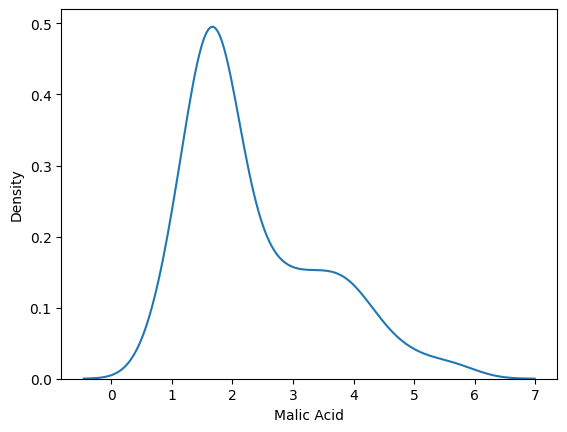

In [27]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

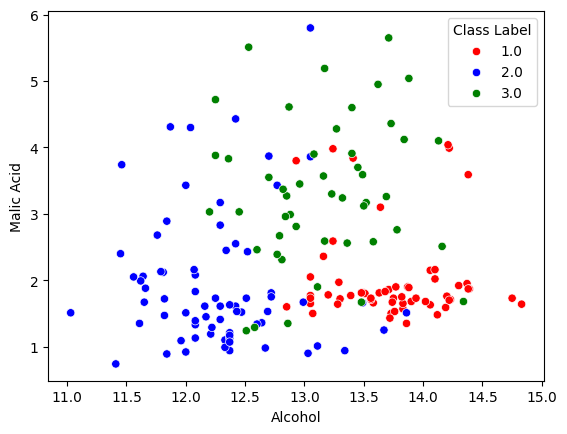

In [32]:
df['Class Label'] = pd.to_numeric(df['Class Label'], errors='coerce')
color_dict = {1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue=df['Class Label'],palette=color_dict)


In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop('Class Label',axis=1),df['Class Label'],test_size=0.3,random_state=0)
X_train.shape, X_test.shape

((125, 2), (54, 2))

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#fit the scaler to training data for it to learn the parameters
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

In [36]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.3
std,0.9,1.1
min,11.0,0.7
25%,12.3,1.5
50%,13.0,1.8
75%,13.7,3.0
max,14.8,5.6


In [37]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


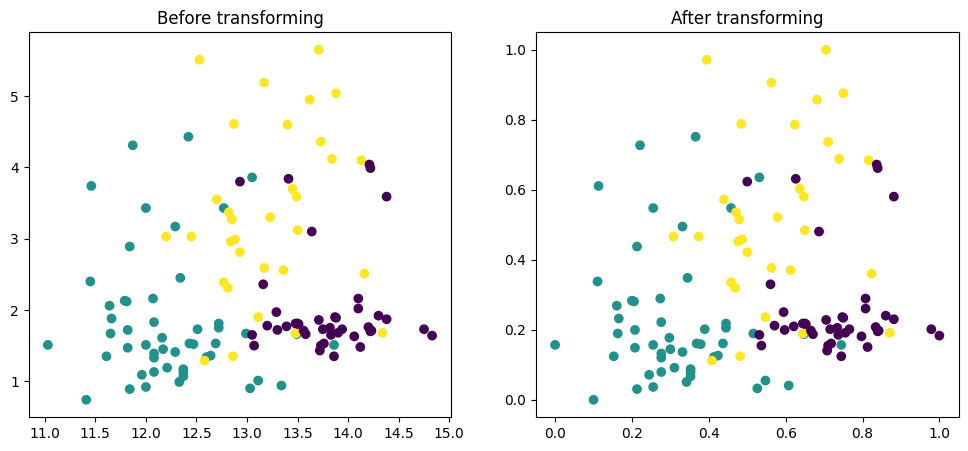

In [41]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'],c=y_train)
ax1.set_title("Before transforming")
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic Acid'],c=y_train)
ax2.set_title("After transforming")
plt.show()

MEAN NORMALIZATION

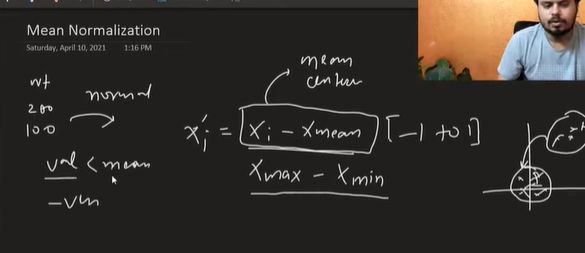

MaxAbsScaling

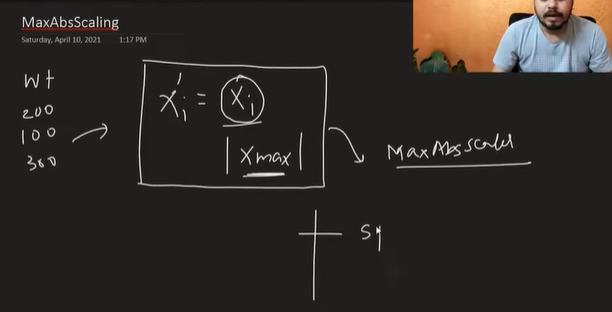

IMPORTANT
ROBUST SCALING

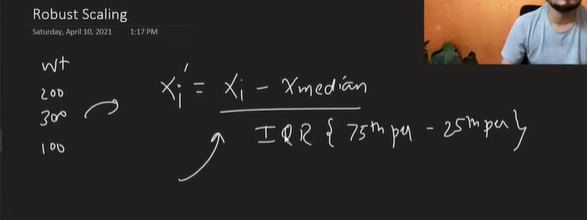

AS NAME SUGGEST IT IS ROBUST TO OUTLIERS

GENERAL TIPS
1) IF OUTLIERS USE ROBUST SCALER
2) IF U KNOW MIN MAX THEN USE MIN-MAX SCALER
3) GENERALLY STANDARDIZATION IS USED MOSTLY